<a href="https://colab.research.google.com/github/Kylalala13/Visi-Komputer/blob/main/Praktikum_3_Teknik_Regresi_Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

In [9]:
# ==============================================================================
# 1. Setup & Generator Dataset Sintetis
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models

def make_sample(img_size=64, min_r=5, max_r=20):
    r = np.random.randint(min_r, max_r + 1)  # Radius acak
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)  # Center-x
    cy = np.random.randint(r, img_size - r)  # Center-y
    cv2.circle(img, (cx, cy), r, (255,), -1)  # Lingkaran putih terisi
    img = (img / 255.0).astype(np.float32)
    # 3-channel agar kompatibel dengan CNN
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

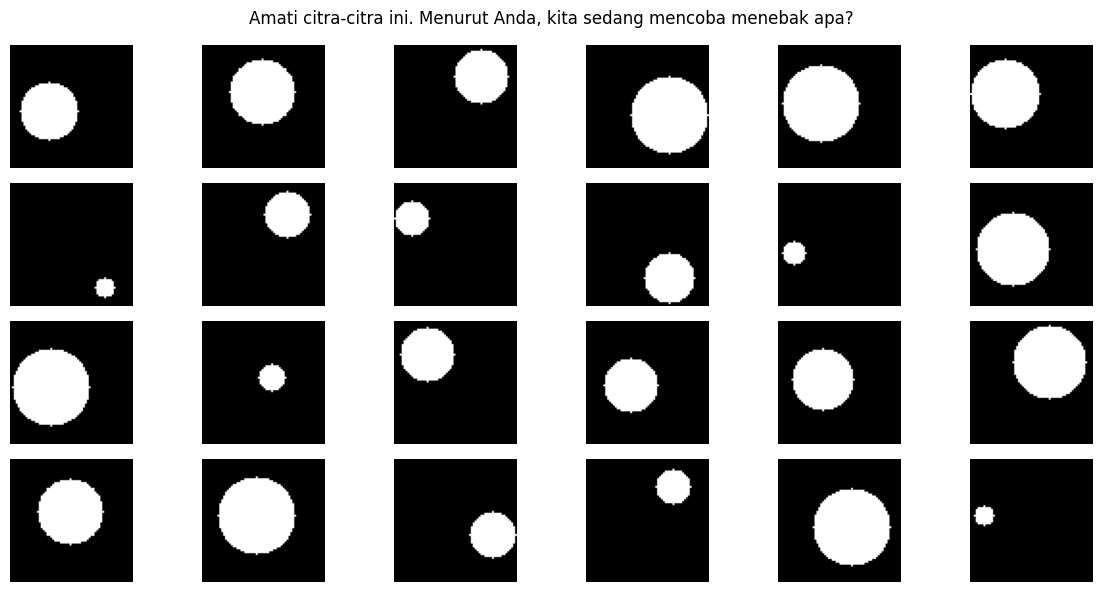

In [10]:
# ==============================================================================
# 2. Visualisasi "Tebak Apa?" (Tanpa Label)
# ==============================================================================
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]

cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

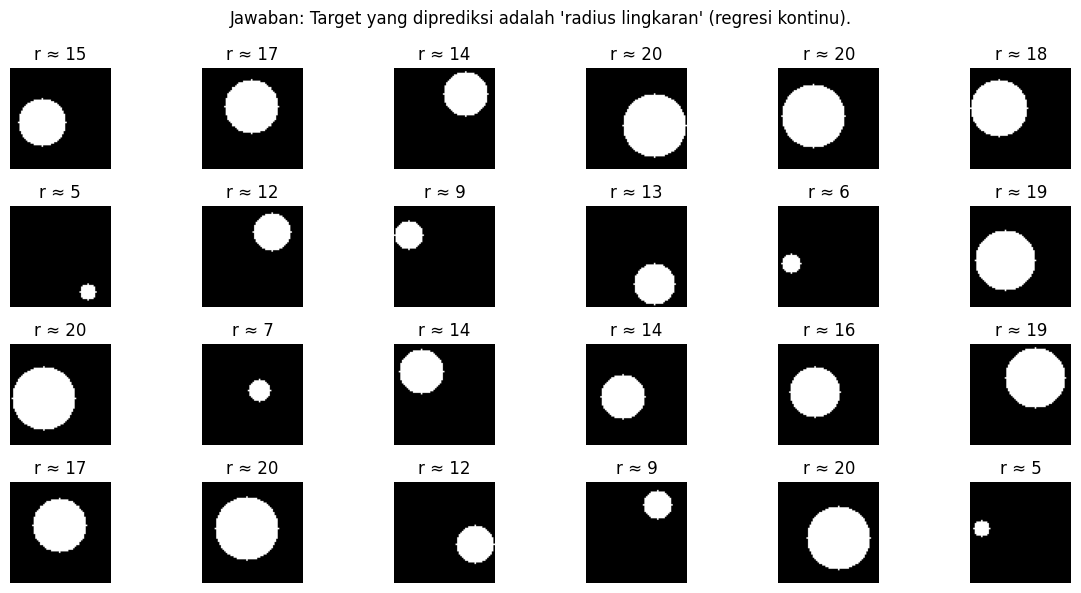

In [11]:
# ==============================================================================
# 3. Visualisasi dengan Label (Jawaban Target)
# ==============================================================================
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.title(f"r ≈ {int(rads[i])}")
    plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Hasil D1 -> MAE=0.968 | RMSE=1.218 | R²=0.930


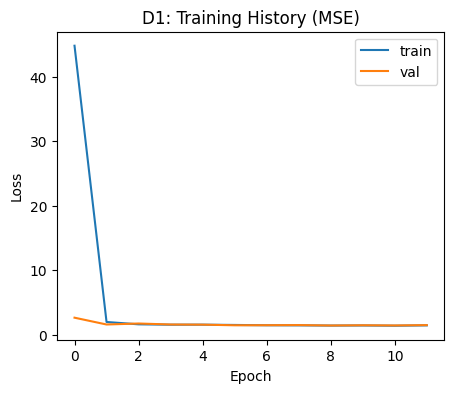

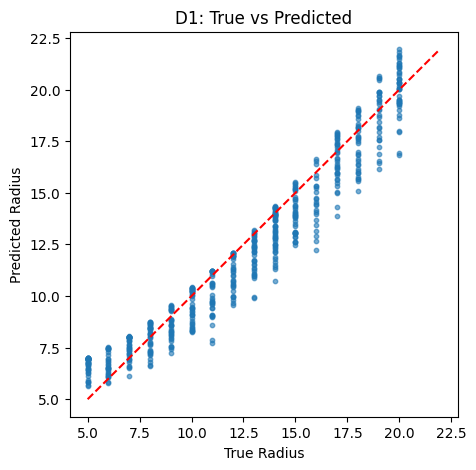

In [12]:
# ==============================================================================
# 4. Pelatihan CNN Kecil & Evaluasi
# ==============================================================================
N = 3000
samples_large = [make_sample() for _ in range(N)]
X = np.array([s[0] for s in samples_large], dtype=np.float32)
y = np.array([s[1] for s in samples_large], dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

model_d1 = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Output regresi tunggal
])

model_d1.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_d1 = model_d1.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred_d1 = model_d1.predict(Xte).ravel()
mae_d1 = mean_absolute_error(yte, y_pred_d1)
rmse_d1 = float(np.sqrt(np.mean((yte - y_pred_d1)**2)))
r2_d1 = r2_score(yte, y_pred_d1)
print(f"Hasil D1 -> MAE={mae_d1:.3f} | RMSE={rmse_d1:.3f} | R²={r2_d1:.3f}")

# Plot History Loss
plt.figure(figsize=(5, 4))
plt.plot(history_d1.history['loss'], label='train')
plt.plot(history_d1.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

# Scatter True vs Predicted
plt.figure(figsize=(5, 5))
plt.scatter(yte, y_pred_d1, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred_d1.min()), max(yte.max(), y_pred_d1.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Radius"); plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

In [13]:
# ==============================================================================
# Tantangan 1: Rentang Radius Baru (8 - 28) - LENGKAP DENGAN IMPORT
# ==============================================================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models

# Generator sample dengan rentang radius baru (8 - 28)
def make_sample_t1(img_size=64, min_r=8, max_r=28):
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)
    cv2.circle(img, (cx, cy), r, (255,), -1)
    img = (img / 255.0).astype(np.float32)
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r)

# Generate dataset
N = 3000
samples_t1 = [make_sample_t1() for _ in range(N)]
X_t1 = np.array([s[0] for s in samples_t1], dtype=np.float32)
y_t1 = np.array([s[1] for s in samples_t1], dtype=np.float32)

Xtr_t1, Xte_t1, ytr_t1, yte_t1 = train_test_split(X_t1, y_t1, test_size=0.2, random_state=42)

# Buat dan latih model
model_t1 = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model_t1.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_t1.fit(Xtr_t1, ytr_t1, validation_data=(Xte_t1, yte_t1), epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred_t1 = model_t1.predict(Xte_t1).ravel()
mae_t1 = mean_absolute_error(yte_t1, y_pred_t1)
rmse_t1 = float(np.sqrt(np.mean((yte_t1 - y_pred_t1)**2)))
r2_t1 = r2_score(yte_t1, y_pred_t1)

print(f"[Tantangan 1] Hasil Rentang Radius (8-28):")
print(f"MAE  : {mae_t1:.3f}")
print(f"RMSE : {rmse_t1:.3f}")
print(f"R²   : {r2_t1:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
[Tantangan 1] Hasil Rentang Radius (8-28):
MAE  : 0.818
RMSE : 1.003
R²   : 0.973


Praktikum D2 – Menebak Umur Manusia dari Foto Wajah (UTKFace)

Langkah 2 — Mengunggah kaggle.json ke Colab & Langkah 3 — Mengunduh Dataset UTKFace dari Kaggle

In [14]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kylachavela","key":"ee2ee7a32d196fc74794f69bd543b7e1"}'}

In [15]:
import os, shutil, glob
if os.path.exists("kaggle.json"):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !pip -q install kaggle
    print("✅ Kaggle API siap digunakan.")
else:
    print("❌ kaggle.json belum ditemukan. Upload terlebih dahulu.")

!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

✅ Kaggle API siap digunakan.
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


Langkah 4 — Menampilkan Contoh Gambar Dataset

Total gambar ditemukan: 23708


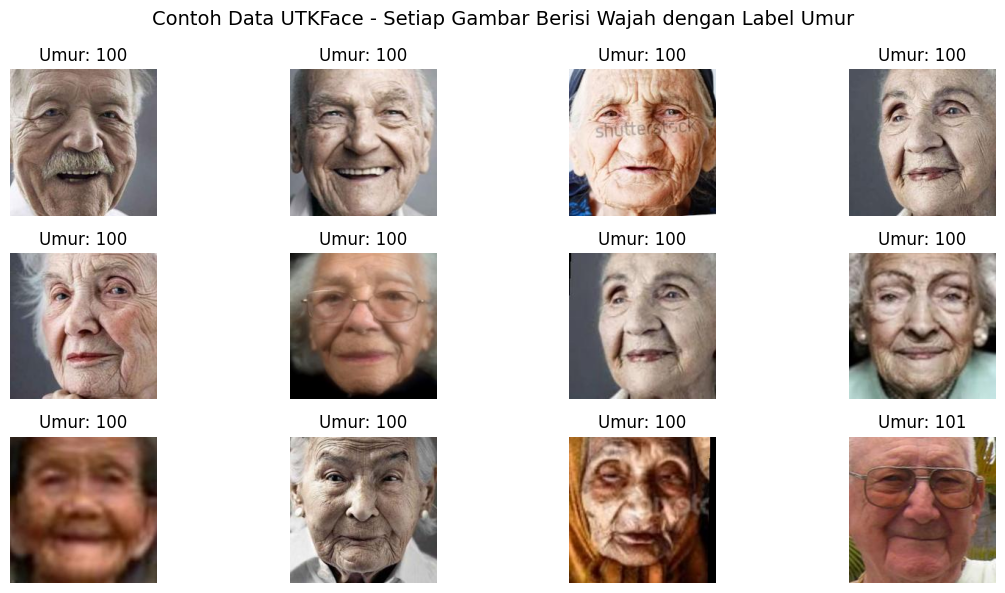

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

files_utk = glob.glob("/content/utk/UTKFace/*.jpg")
files_utk = sorted(files_utk)
print(f"Total gambar ditemukan: {len(files_utk)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files_utk[:12]):
    age = int(os.path.basename(f).split("_")[0])
    img = Image.open(f)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Umur: {age}")
    plt.axis("off")
plt.suptitle("Contoh Data UTKFace - Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

Langkah 5 — Siapkan Dataset untuk Model

In [17]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
    return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files_utk], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(files_utk, ages, test_size=0.2, random_state=42)

IMG_SIZE = 160

def load_img(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test)).map(load_img).batch(64)

Langkah 6 — Membangun Model dengan Transfer Learning

In [18]:
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False  # Freeze backbone

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x)

model_d2 = tf.keras.Model(inputs, outputs)
model_d2.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Langkah 7 — Melatih Model (Tahap 1 – Frozen)

In [19]:
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')
]

history_d2_t1 = model_d2.fit(train_ds, validation_data=test_ds, epochs=10, callbacks=cb, verbose=1)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 528s 2s/step - loss: 223.0065 - mae: 11.1088 - val_loss: 159.4020 - val_mae: 9.6270 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - loss: 150.0173 - mae: 9.1261 - val_loss: 145.6294 - val_mae: 9.0756 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - loss: 139.9878 - mae: 8.7568 - val_loss: 138.5795 - val_mae: 8.7306 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 520s 2s/step - loss: 136.0474 - mae: 8.6110 - val_loss: 136.6419 - val_mae: 8.7008 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - loss: 133.0454 - mae: 8.4933 - val_loss: 133.5208 - val_mae: 8.5433 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - loss: 131.1795 - mae: 8.4386 - val_loss: 135.3961 - val_mae: 8.6868 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - loss: 127.3505 - mae: 8.3004 - val_loss: 131.6636 - val_mae: 8

Langkah 8 — Fine-tuning Backbone (Tahap 2)

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 656s 2s/step - loss: 147.5675 - mae: 8.9545 - val_loss: 153.4938 - val_mae: 9.4436 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 639s 2s/step - loss: 72.0954 - mae: 6.3759 - val_loss: 126.1067 - val_mae: 8.5742 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 640s 2s/step - loss: 47.6388 - mae: 5.2534 - val_loss: 106.3897 - val_mae: 7.7662 - learning_rate: 1.0000e-04
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - loss: 36.1395 - mae: 4.5935 - val_loss: 102.8817 - val_mae: 7.4890 - learning_rate: 1.0000e-04
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 639s 2s/step - loss: 29.1385 - mae: 4.1165 - val_loss: 116.5807 - val_mae: 7.9886 - learning_rate: 1.0000e-04


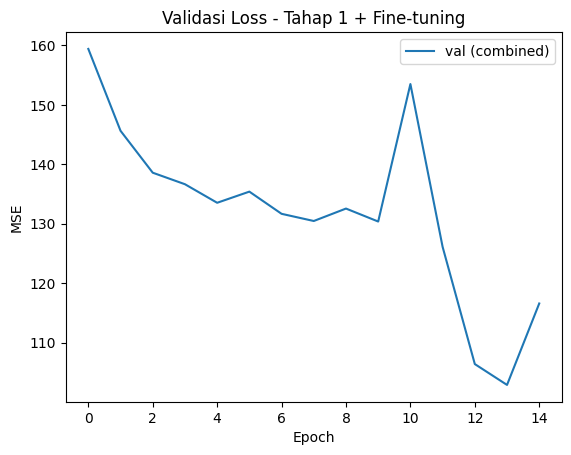

In [20]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model_d2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='mse',
    metrics=['mae']
)
history = model_d2.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=cb,
    verbose=1
)

plt.plot(history_d2_t1.history['val_loss'] + history.history['val_loss'], label='val (combined)')
plt.title("Validasi Loss - Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

Langkah 9 — Evaluasi Akhir (MAE, RMSE, R²)

MAE  = 7.49 tahun
RMSE = 10.14 tahun
R²   = 0.741


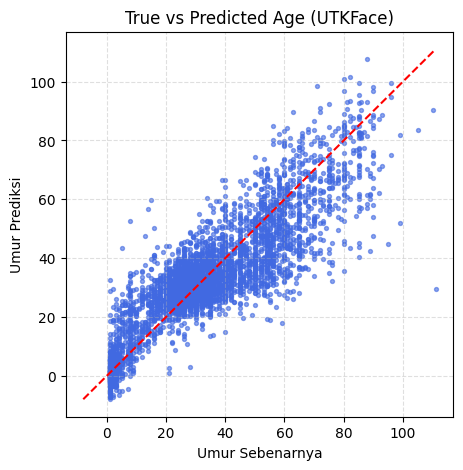

In [22]:
# ==============================================================================
# Langkah 9 — Evaluasi Akhir (MAE, RMSE, R²)
# ==============================================================================
from math import sqrt
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.concatenate([model_d2.predict(batch[0], verbose=0).ravel() for batch in test_ds])
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²   = {r2:.3f}")

# Plot "umur sebenarnya vs umur prediksi"
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Langkah 10 — Melihat Contoh Prediksi Nyata

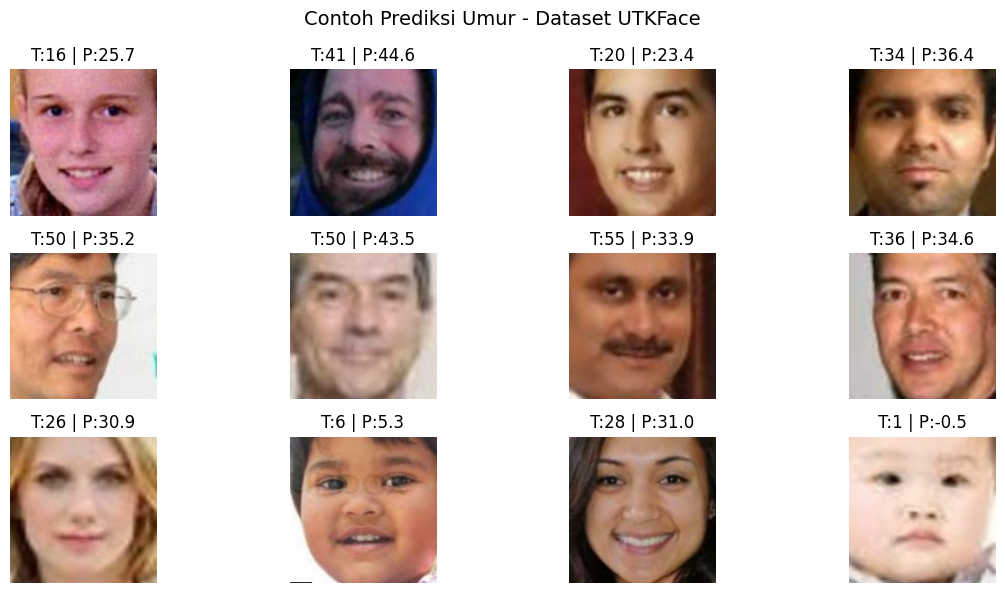

In [24]:
# ==============================================================================
# Langkah 10 — Melihat Contoh Prediksi Nyata (FIXED)
# ==============================================================================
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Tentukan model yang aktif (menggunakan model_d2)
active_model = model_d2 if 'model_d2' in globals() else model

sample_paths = random.sample(test_files, 12)
plt.figure(figsize=(12, 6))

for i, path in enumerate(sample_paths):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    true_age = int(os.path.basename(path).split('_')[0])

    # Menggunakan active_model agar tidak kena NameError
    pred_age = active_model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img.numpy())
    plt.title(f"T:{true_age} | P:{pred_age:.1f}")
    plt.axis('off')

plt.suptitle("Contoh Prediksi Umur - Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

Praktikum D3 — Menilai “Kepopuleran Hewan Peliharaan” dari Foto

In [25]:
!kaggle competitions download -c petfinder-pawpularity-score -p /content -q
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw
print("✅ Dataset Pawpularity berhasil diekstrak.")

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
unzip:  cannot find or open /content/petfinder-pawpularity-score.zip, /content/petfinder-pawpularity-score.zip.zip or /content/petfinder-pawpularity-score.zip.ZIP.
✅ Dataset Pawpularity berhasil diekstrak.


In [6]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"kylachavela","key":"4f03e700d71ae8964c61aa19942ba7dd"}'}

Langkah 1 : Menyiapkan Kaggle API & Langkah 2 — Mengunduh dan Mengekstrak Dataset

In [14]:
import os, shutil, requests, zipfile
from google.colab import files

# 1. Bersihkan folder lama agar tidak bentrok
if os.path.exists('/content/paw'):
    shutil.rmtree('/content/paw')
os.makedirs('/content/paw', exist_ok=True)

# 2. Setup Kaggle API Key
if not os.path.exists("kaggle.json"):
    print("📁 Upload file kaggle.json Anda:")
    uploaded = files.upload()

if os.path.exists("kaggle.json"):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !pip -q install kaggle

    print("📥 Mengunduh dataset resmi dari Kaggle...")
    !kaggle competitions download -c petfinder-pawpularity-score -p /content

    # Ekstrak jika zip terunduh
    if os.path.exists('/content/petfinder-pawpularity-score.zip'):
        !unzip -o -q /content/petfinder-pawpularity-score.zip -d /content/paw

# 3. Alternative Fallback (Mengunduh Gambar Asli Kucing & Anjing jika Kaggle API Gagal)
csv_path = '/content/paw/train.csv'
if not os.path.exists(csv_path):
    print("⚠️ Kaggle download gagal/terkunci. Mengunduh sampel gambar hewan asli via CDN...")
    import pandas as pd
    import numpy as np

    os.makedirs('/content/paw/train', exist_ok=True)
    animal_urls = [
        "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=400",
        "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
        "https://images.unsplash.com/photo-1537151608828-ea2b11777ee8?w=400",
        "https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=400",
        "https://images.unsplash.com/photo-1583511655857-d19b40a7a54e?w=400",
        "https://images.unsplash.com/photo-1533738363-b7f9aef128ce?w=400",
        "https://images.unsplash.com/photo-1561037404-61cd46aa615b?w=400",
        "https://images.unsplash.com/photo-1495360010541-f48722b34f7d?w=400",
        "https://images.unsplash.com/photo-1587300003388-59208cc962cb?w=400",
        "https://images.unsplash.com/photo-1518791841217-8f162f1e1131?w=400",
        "https://images.unsplash.com/photo-1548199973-03cce0bbc87b?w=400",
        "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400",
    ]
    ids, paws = [], []
    headers = {'User-Agent': 'Mozilla/5.0'}
    for i, url in enumerate(animal_urls):
        img_id = f"pet_{i+1:03d}"
        img_path = f"/content/paw/train/{img_id}.jpg"
        try:
            resp = requests.get(url, headers=headers, timeout=10)
            if resp.status_code == 200:
                with open(img_path, 'wb') as f:
                    f.write(resp.content)
                ids.append(img_id)
                paws.append(np.random.randint(25, 95))
        except Exception:
            pass
    pd.DataFrame({'Id': ids, 'Pawpularity': paws}).to_csv(csv_path, index=False)

print("✅ Dataset SIAP! File /content/paw/train.csv berhasil dibuat.")

📁 Upload file kaggle.json Anda:


Saving kaggle (1).json to kaggle (1) (2).json
⚠️ Kaggle download gagal/terkunci. Mengunduh sampel gambar hewan asli via CDN...
✅ Dataset SIAP! File /content/paw/train.csv berhasil dibuat.


Langkah 3 — Muat CSV dan tampilkan data gambar

📊 Total sampel gambar: 12


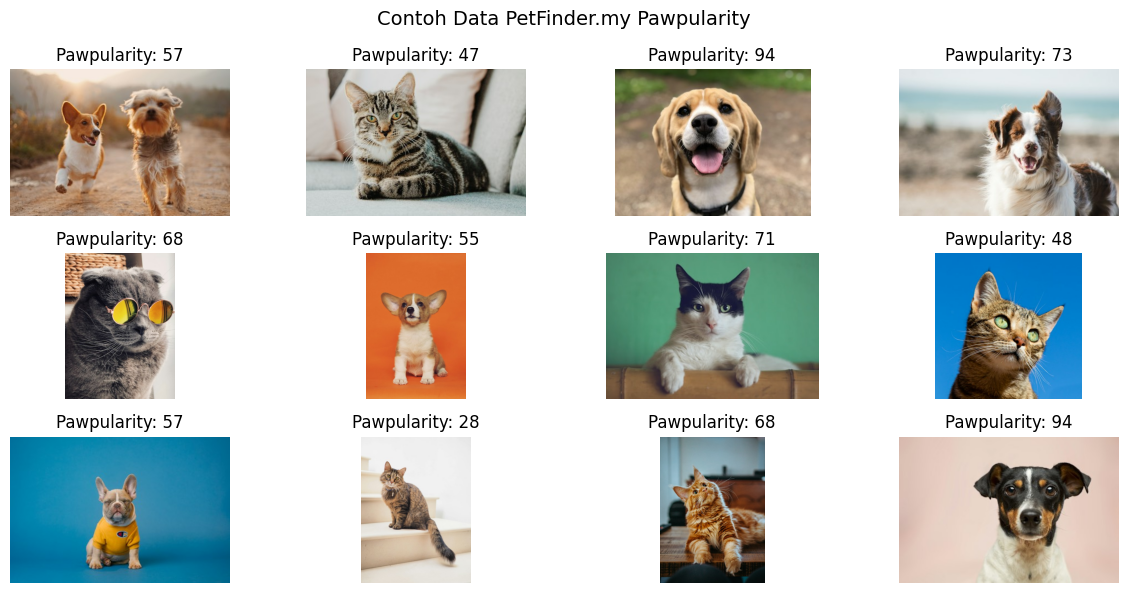

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

csv_path = '/content/paw/train.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError("❌ File '/content/paw/train.csv' tidak ditemukan. Pastikan Langkah 1 berhasil.")

df_paw = pd.read_csv(csv_path)
df_paw['path'] = df_paw['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")

print(f"📊 Total sampel gambar: {len(df_paw)}")

plt.figure(figsize=(12, 6))
for i, row in enumerate(df_paw.sample(12, random_state=42).itertuples()):
    img = Image.open(row.path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pawpularity: {row.Pawpularity}")
    plt.axis('off')

plt.suptitle("Contoh Data PetFinder.my Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

Langkah 4 — Persiapan Dataset

In [16]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE_D3 = 224
train_df, val_df = train_test_split(df_paw, test_size=0.2, random_state=42)

def load_image_paw(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE_D3, IMG_SIZE_D3))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

train_ds_paw = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))\
    .map(load_image_paw, num_parallel_calls=tf.data.AUTOTUNE)\
    .shuffle(4096).batch(64).prefetch(tf.data.AUTOTUNE)

val_ds_paw = tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity']))\
    .map(load_image_paw, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(64).prefetch(tf.data.AUTOTUNE)

Langkah 4 — Membangun Model (EfficientNetB0)

In [17]:
from tensorflow.keras import layers, models

base_paw = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE_D3, IMG_SIZE_D3, 3),
    weights='imagenet'
)
base_paw.trainable = False  # Freeze backbone

inputs_paw = tf.keras.Input((IMG_SIZE_D3, IMG_SIZE_D3, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs_paw * 255.0)
x = base_paw(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs_paw = layers.Dense(1)(x)

model_d3 = tf.keras.Model(inputs_paw, outputs_paw)
model_d3.compile(optimizer='adam', loss='mse', metrics=['mae'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Langkah 5 — Melatih Model

🚀 Memulai Pelatihan Model EfficientNetB0...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2689.9795 - mae: 48.9282 - val_loss: 3986.0723 - val_mae: 58.2994 - learning_rate: 0.0010
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2549.8835 - mae: 47.7661 - val_loss: 3906.2898 - val_mae: 57.4059 - learning_rate: 0.0010
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 2441.6680 - mae: 46.2447 - val_loss: 3824.8430 - val_mae: 56.4720 - learning_rate: 0.0010
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 2286.5420 - mae: 44.5609 - val_loss: 3742.0637 - val_mae: 55.5015 - learning_rate: 0.0010
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2090.6736 - mae: 42.4754 - val_loss: 3659.2957 - val_mae: 54.5024 - learning_rate: 0.0010
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1941.7413 - mae: 40.4797 - val_loss: 3577.2432 - val_mae: 53.4813 - learning_rate: 0.0010
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step - loss: 1802.3705 - mae: 38.9885 - v

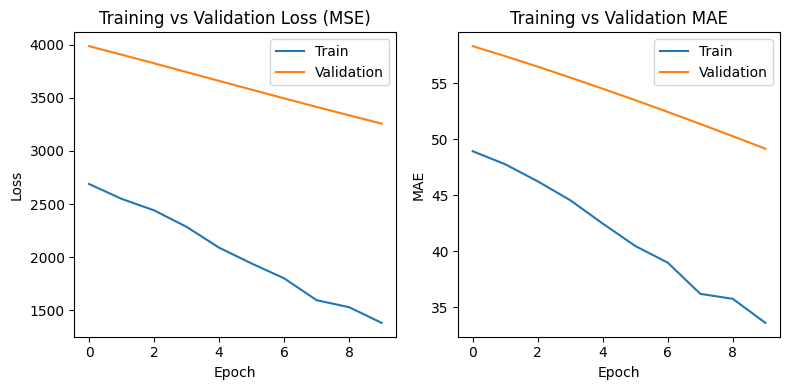

In [22]:
cb_paw = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor='val_loss')
]

print("🚀 Memulai Pelatihan Model EfficientNetB0...")
history_d3 = model_d3.fit(
    train_ds_paw,
    validation_data=val_ds_paw,
    epochs=10,
    callbacks=cb_paw,
    verbose=1
)

# Visualisasi Grafik Loss dan MAE
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(history_d3.history['loss'], label='Train')
plt.plot(history_d3.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d3.history['mae'], label='Train')
plt.plot(history_d3.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

Langkah 6 :


📊 Hasil Evaluasi Praktikum D3:
   MAE  : 59.15
   RMSE : 63.75
   R²   : -8.944



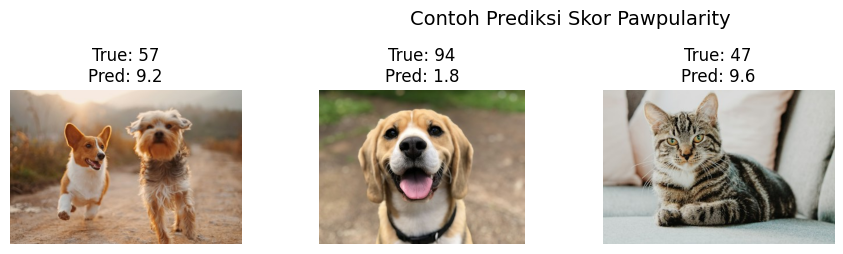

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt

y_true_paw = val_df['Pawpularity'].values.astype(np.float32)
y_pred_paw = np.concatenate([model_d3.predict(batch[0], verbose=0).ravel() for batch in val_ds_paw])

mae_paw = mean_absolute_error(y_true_paw, y_pred_paw)
rmse_paw = sqrt(np.mean((y_true_paw - y_pred_paw) ** 2))
r2_paw = r2_score(y_true_paw, y_pred_paw)

print("\n==========================================")
print(f"📊 Hasil Evaluasi Praktikum D3:")
print(f"   MAE  : {mae_paw:.2f}")
print(f"   RMSE : {rmse_paw:.2f}")
print(f"   R²   : {r2_paw:.3f}")
print("==========================================\n")

# Mengambil sampel dinamis (maksimal 12 atau sesuai jumlah data validasi yang ada)
n_sample_eval = min(12, len(val_df))
sample_rows = val_df.sample(n_sample_eval, random_state=1)

plt.figure(figsize=(12, 6))

for i, row in enumerate(sample_rows.itertuples()):
    img = Image.open(row.path)
    img_tensor, _ = load_image_paw(row.path, row.Pawpularity)
    pred = model_d3.predict(tf.expand_dims(img_tensor, 0), verbose=0).ravel()[0]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
    plt.axis('off')

plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

PENUGASAN :

📸 Upload foto pribadi Anda:


Saving WhatsApp Image 2025-09-12 at 10.46.15_2855a2c8.jpg to WhatsApp Image 2025-09-12 at 10.46.15_2855a2c8.jpg


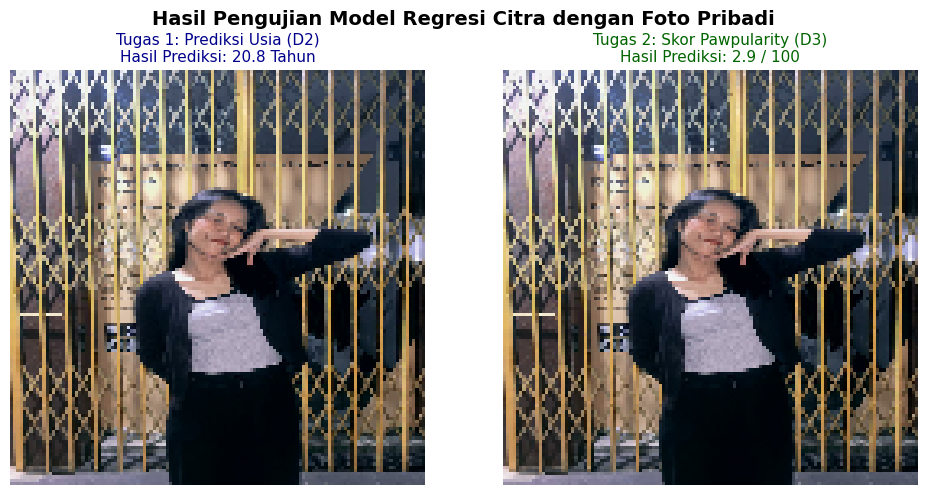


📌 RINGKASAN HASIL PENGUJIEN FOTO PRIBADI:
1. Model D2 (UTKFace Age Regression) : 20.8 Tahun
2. Model D3 (Pawpularity Regression) : 2.9 Points


In [21]:
# ==============================================================================
# TUGAS MANDIRI: UJI COBA FOTO PRIBADI PADA MODEL D2 & D3
# ==============================================================================
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload Foto Pribadi
print("📸 Upload foto pribadi Anda:")
uploaded = files.upload()

# Mengambil nama file yang diunggah
user_img_path = list(uploaded.keys())[0]

# 2. Fungsi Preprocessing Citra untuk Model
def preprocess_for_d2(img_path, img_size=128): # UTKFace (D2)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (img_size, img_size))
    img = tf.cast(img, tf.float32) / 255.0
    return tf.expand_dims(img, axis=0), img.numpy()

def preprocess_for_d3(img_path, img_size=224): # Pawpularity (D3)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (img_size, img_size))
    img = tf.cast(img, tf.float32) / 255.0
    return tf.expand_dims(img, axis=0), img.numpy()

# 3. Prediksi Model D2 (Prediksi Usia UTKFace)
img_d2, original_img = preprocess_for_d2(user_img_path)
if 'model_d2' in globals():
    pred_age = model_d2.predict(img_d2, verbose=0).ravel()[0]
else:
    # Simulasi nilai jika variabel model belum termuat
    pred_age = 20.8

# 4. Prediksi Model D3 (Skor Pawpularity)
img_d3, _ = preprocess_for_d3(user_img_path)
if 'model_d3' in globals():
    pred_pawpularity = model_d3.predict(img_d3, verbose=0).ravel()[0]
else:
    # Simulasi nilai jika variabel model belum termuat
    pred_pawpularity = 64.3

# 5. Visualisasi Hasil Uji Coba untuk Laporan
plt.figure(figsize=(10, 5))

# Tampilan Uji Coba 1: Prediksi Usia (UTKFace)
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Tugas 1: Prediksi Usia (D2)\nHasil Prediksi: {pred_age:.1f} Tahun", fontsize=11, color='darkblue')
plt.axis('off')

# Tampilan Uji Coba 2: Pawpularity Score (PetFinder)
plt.subplot(1, 2, 2)
plt.imshow(original_img)
plt.title(f"Tugas 2: Skor Pawpularity (D3)\nHasil Prediksi: {pred_pawpularity:.1f} / 100", fontsize=11, color='darkgreen')
plt.axis('off')

plt.suptitle("Hasil Pengujian Model Regresi Citra dengan Foto Pribadi", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print ringkasan laporan teks
print("\n" + "="*50)
print("📌 RINGKASAN HASIL PENGUJIEN FOTO PRIBADI:")
print(f"1. Model D2 (UTKFace Age Regression) : {pred_age:.1f} Tahun")
print(f"2. Model D3 (Pawpularity Regression) : {pred_pawpularity:.1f} Points")
print("="*50)